In [1]:
pip install catboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install scikit-optimize

Note: you may need to restart the kernel to use updated packages.


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


# Reading the dataset

In [4]:
data=pd.read_csv('/kaggle/input/datasets/rikufootballcorner/web-analytics/online_shoppers_intention.csv')
data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [5]:
data.shape

(12330, 18)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [7]:
data['VisitorType'].head()

0    Returning_Visitor
1    Returning_Visitor
2    Returning_Visitor
3    Returning_Visitor
4    Returning_Visitor
Name: VisitorType, dtype: object

In [8]:
data['Month'].value_counts()

Month
May     3364
Nov     2998
Mar     1907
Dec     1727
Oct      549
Sep      448
Aug      433
Jul      432
June     288
Feb      184
Name: count, dtype: int64

# Checking for missing values

In [9]:
mv=data.isnull().sum()
mv

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

There are no missing values in the dataset

In [10]:
data.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

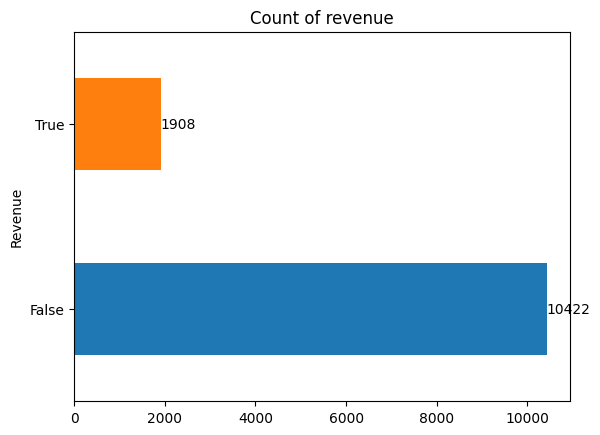

In [11]:
counts = data['Revenue'].value_counts()

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']  # add more if needed

ax = counts.plot(kind='barh', color=colors)

for bar in ax.patches:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    ax.text(width, y, int(width), va='center')
plt.grid(False)
plt.title('Count of revenue')

plt.show()

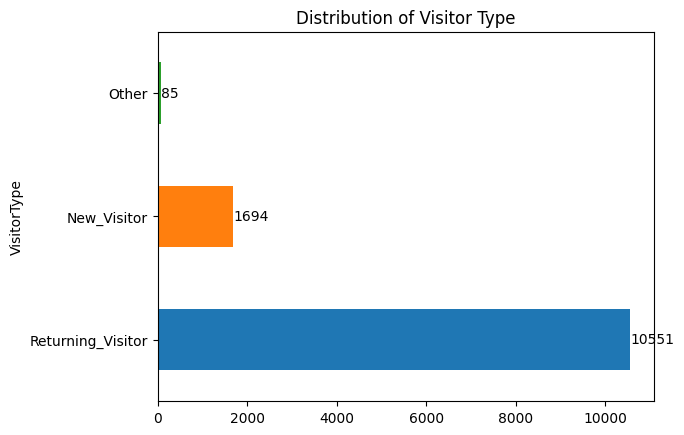

In [12]:
counts = data['VisitorType'].value_counts()

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']  # add more if needed

ax = counts.plot(kind='barh', color=colors)

for bar in ax.patches:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    ax.text(width, y, int(width), va='center')
plt.grid(False)
plt.title('Distribution of Visitor Type')

plt.show()

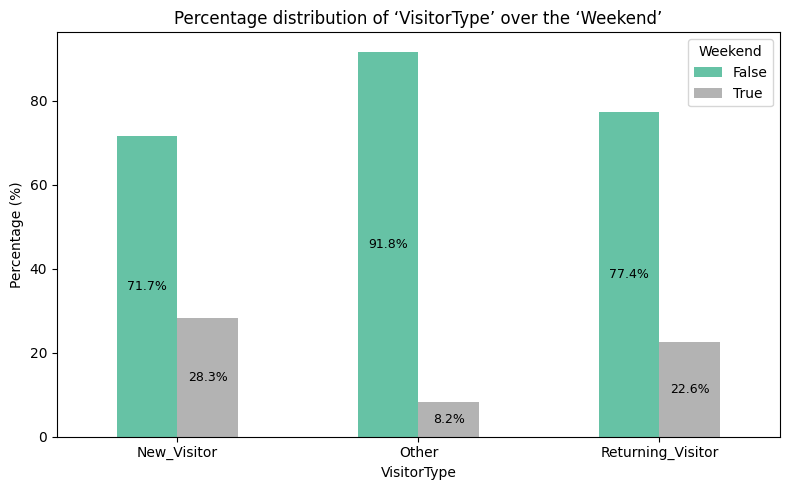

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# Create percentage table
df1 = pd.crosstab(
    data['VisitorType'],
    data['Weekend'],
    normalize='index'
) * 100

# Plot stacked bar chart
ax = df1.plot(
    kind='bar',
    colormap='Set2',
    figsize=(8,5)
)

# Add percentage labels inside bars
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:  # avoid writing 0%
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_y() + height/2,
                f'{height:.1f}%',
                ha='center',
                va='center',
                fontsize=9,
                color='black'
            )

plt.ylabel("Percentage (%)")
plt.title("Percentage distribution of ‘VisitorType’ over the ‘Weekend’")
plt.xticks(rotation=0)
plt.legend(title="Weekend")
plt.tight_layout()
plt.show()

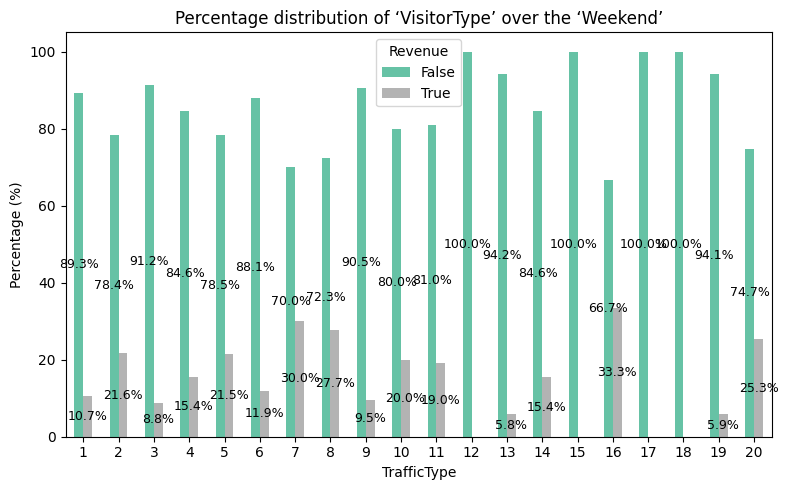

In [14]:
# Create percentage table
df1 = pd.crosstab(
    data['TrafficType'],
    data['Revenue'],
    normalize='index'
) * 100

# Plot stacked bar chart
ax = df1.plot(
    kind='bar',
    colormap='Set2',
    figsize=(8,5)
)

# Add percentage labels inside bars
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:  # avoid writing 0%
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_y() + height/2,
                f'{height:.1f}%',
                ha='center',
                va='center',
                fontsize=9,
                color='black'
            )

plt.ylabel("Percentage (%)")
plt.title("Percentage distribution of ‘VisitorType’ over the ‘Weekend’")
plt.xticks(rotation=0)
plt.legend(title="Revenue")
plt.tight_layout()
plt.show()

Distribution of Customers based on Different Traffic Type Codes

Text(0, 0.5, 'Count')

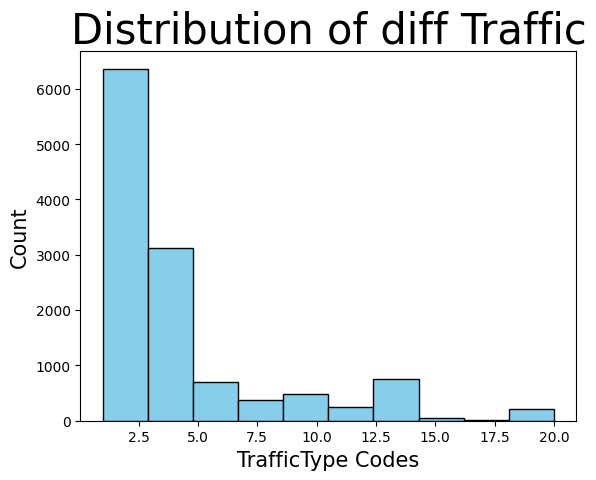

In [15]:
plt.hist(data['TrafficType'], color='skyblue', edgecolor='black')
plt.title('Distribution of diff Traffic',fontsize = 30)
plt.xlabel('TrafficType Codes', fontsize = 15)
plt.ylabel('Count', fontsize = 15)

Distribution of Customers based on Region Codes

Text(0, 0.5, 'Count')

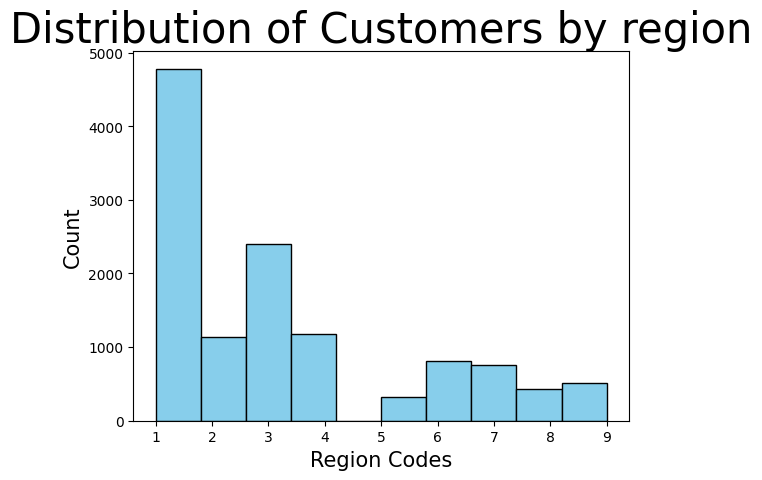

In [16]:
plt.hist(data['Region'], color='skyblue', edgecolor='black')
plt.title('Distribution of Customers by region',fontsize = 30)
plt.xlabel('Region Codes', fontsize = 15)
plt.ylabel('Count', fontsize = 15)

Distribution of Customers over OperatingSystems

Text(0, 0.5, 'Count')

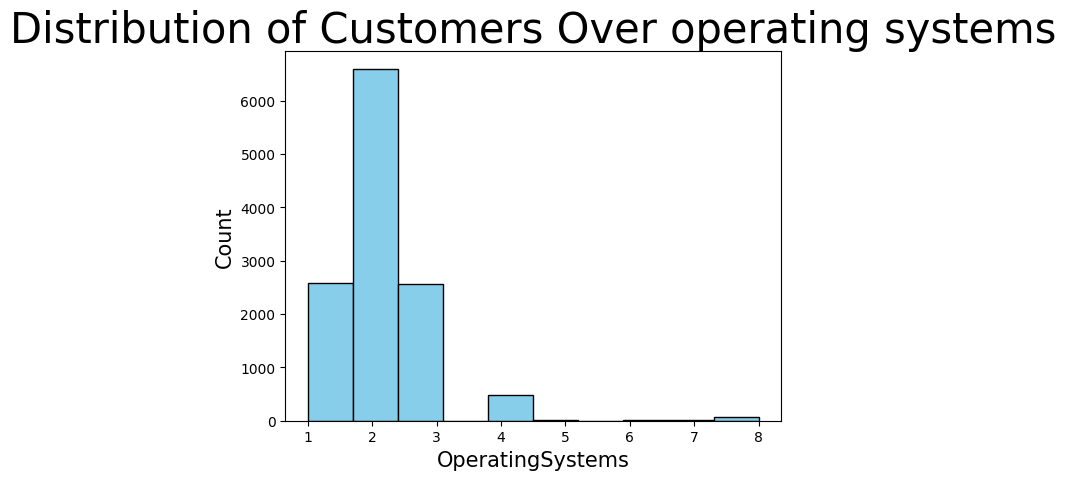

In [17]:
plt.hist(data['OperatingSystems'], color='skyblue', edgecolor='black')
plt.title('Distribution of Customers Over operating systems',fontsize = 30)
plt.xlabel('OperatingSystems', fontsize = 15)
plt.ylabel('Count', fontsize = 15)

Distribution of Customers over Months

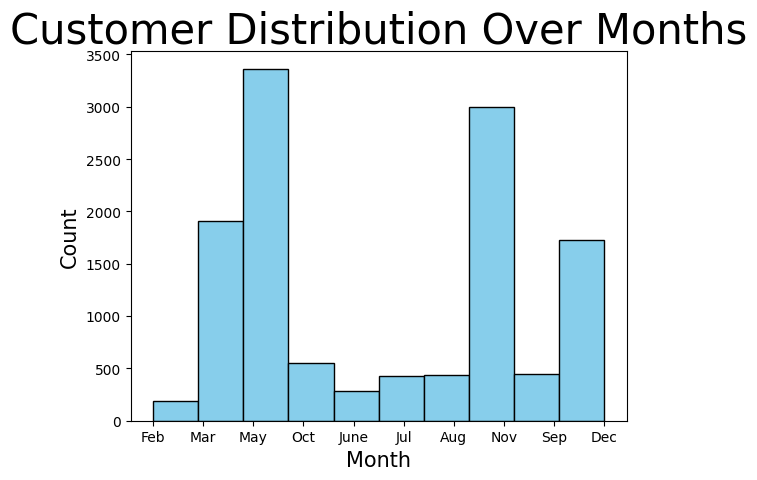

In [18]:

plt.hist(data['Month'], color='skyblue', edgecolor='black')
plt.title('Customer Distribution Over Months',fontsize = 30)
plt.xlabel('Month', fontsize = 15)
plt.ylabel('Count', fontsize = 15);

Distribution of Pagevalues over Revenue.

Text(0.5, 1.0, 'Distribution of Pagevalues over Revenue')

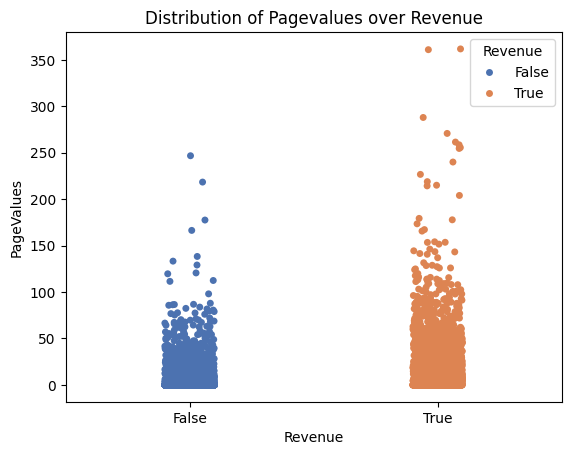

In [19]:
sns.stripplot(data = data, x='Revenue', y='PageValues', hue='Revenue', palette="deep")
plt.title('Distribution of Pagevalues over Revenue')

Distribution of Revenue over BounceRates

Text(0.5, 1.0, 'Distribution of Revenue over BounceRates')

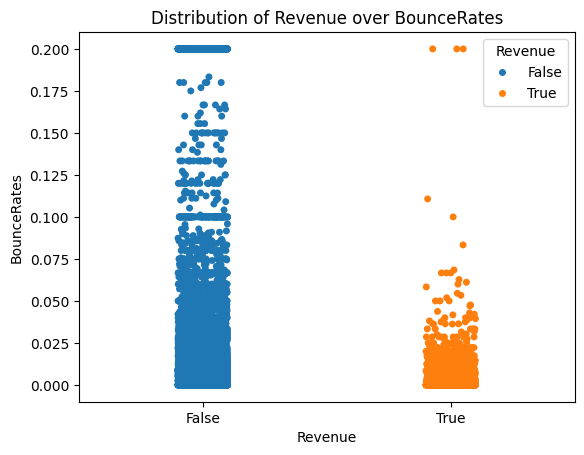

In [20]:






sns.stripplot(data=data, x='Revenue', y='BounceRates', hue= 'Revenue')
plt.title('Distribution of Revenue over BounceRates')

Distribution of TrafficType over Revenue

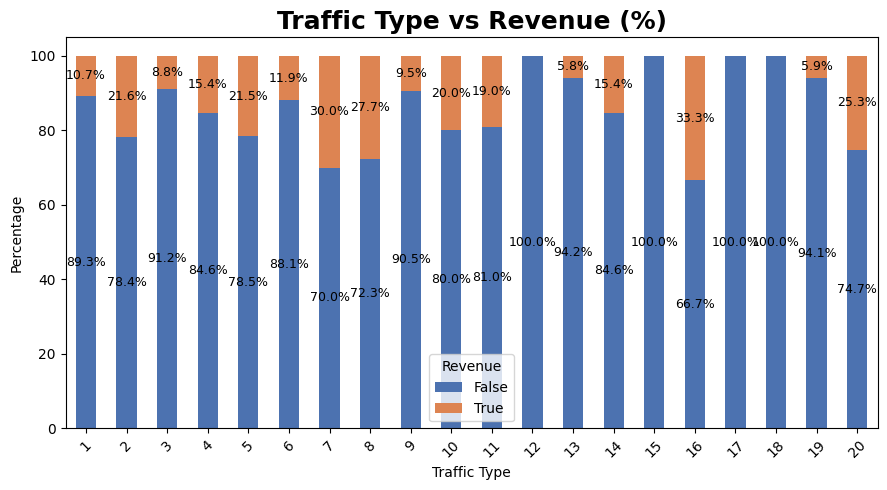

In [21]:
df = pd.crosstab(data['TrafficType'], data['Revenue'])
df_pct = df.div(df.sum(axis=1), axis=0) * 100

# Custom colors (adjust if Revenue has only two categories)
colors = ['#4C72B0', '#DD8452']

ax = df_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(9,5),
    color=colors
)

# Add percentage labels
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 5:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_y() + height/2,
                f'{height:.1f}%',
                ha='center',
                va='center',
                fontsize=9
            )

plt.title('Traffic Type vs Revenue (%)', fontsize=18, weight='bold')
plt.xlabel('Traffic Type')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.legend(title='Revenue')
plt.tight_layout()
plt.show()

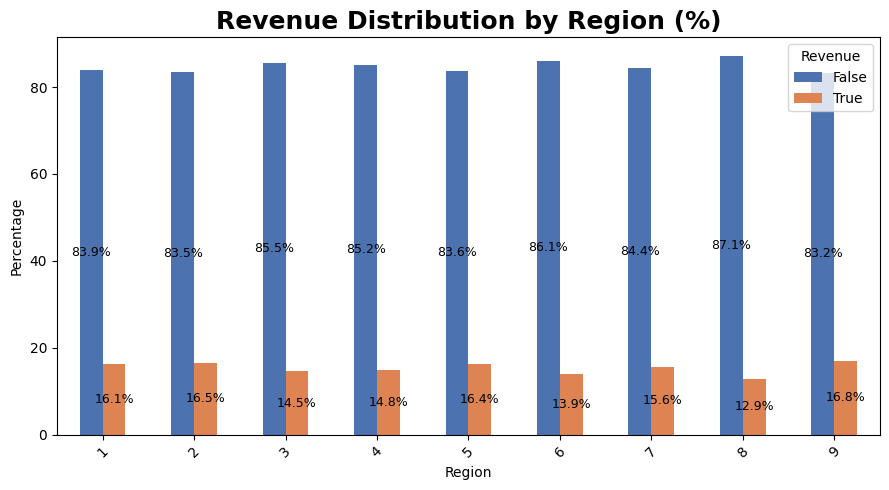

In [22]:
# Create normalized percentages
df_pct = pd.crosstab(data['Region'], data['Revenue'], normalize='index') * 100

# Custom colors
colors = ['#4C72B0', '#DD8452']  # adjust based on number of Revenue categories

# Plot stacked bar chart
ax = df_pct.plot(
    kind='bar',
    color=colors,
    figsize=(9,5)
)

# Add percentage labels
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 5:  # avoid clutter
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_y() + height/2,
                f'{height:.1f}%',
                ha='center',
                va='center',
                fontsize=9
            )

plt.title('Revenue Distribution by Region (%)', fontsize=18, weight='bold')
plt.xlabel('Region')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.legend(title='Revenue')
plt.tight_layout()
plt.show()

Linear Regression plot between Administrative and Informational

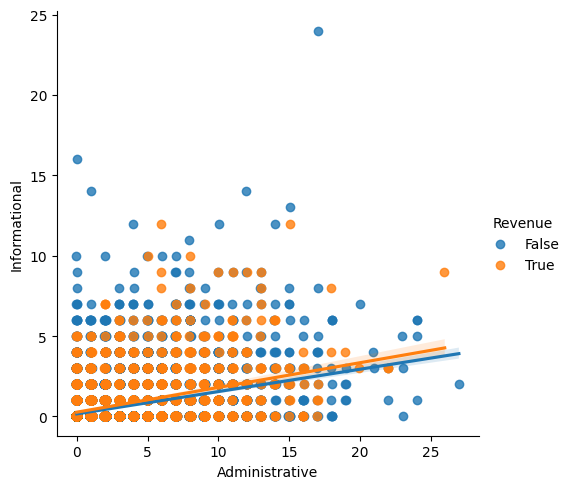

In [23]:
sns.lmplot(x = 'Administrative', y = 'Informational',
           data = data, x_jitter = 0.05, hue='Revenue');

Month vs Pagevalues wrt Revenue

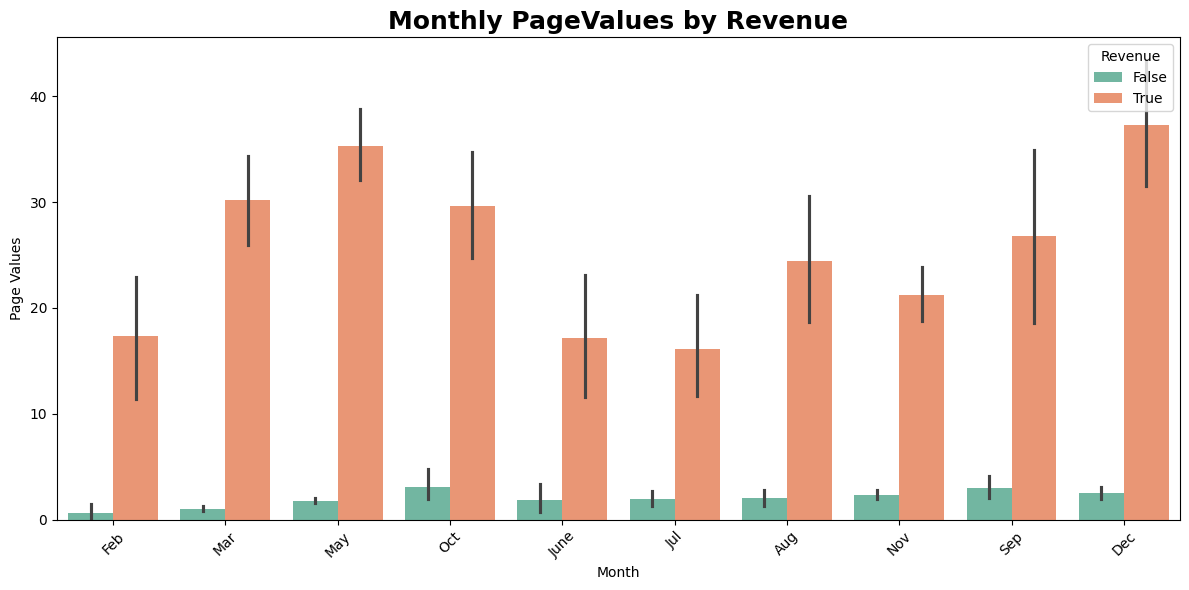

In [24]:
plt.figure(figsize=(12,6))

# Correct Seaborn syntax: pass dataframe and column names
sns.barplot(
    data=data,
    x='Month',
    y='PageValues',
    hue='Revenue',
    palette='Set2'
)

plt.title('Monthly PageValues by Revenue', fontsize=18, weight='bold')
plt.xlabel('Month')
plt.ylabel('Page Values')
plt.xticks(rotation=45)
plt.legend(title='Revenue', loc='upper right')
plt.tight_layout()
plt.show()

month vs bouncerates wrt revenue

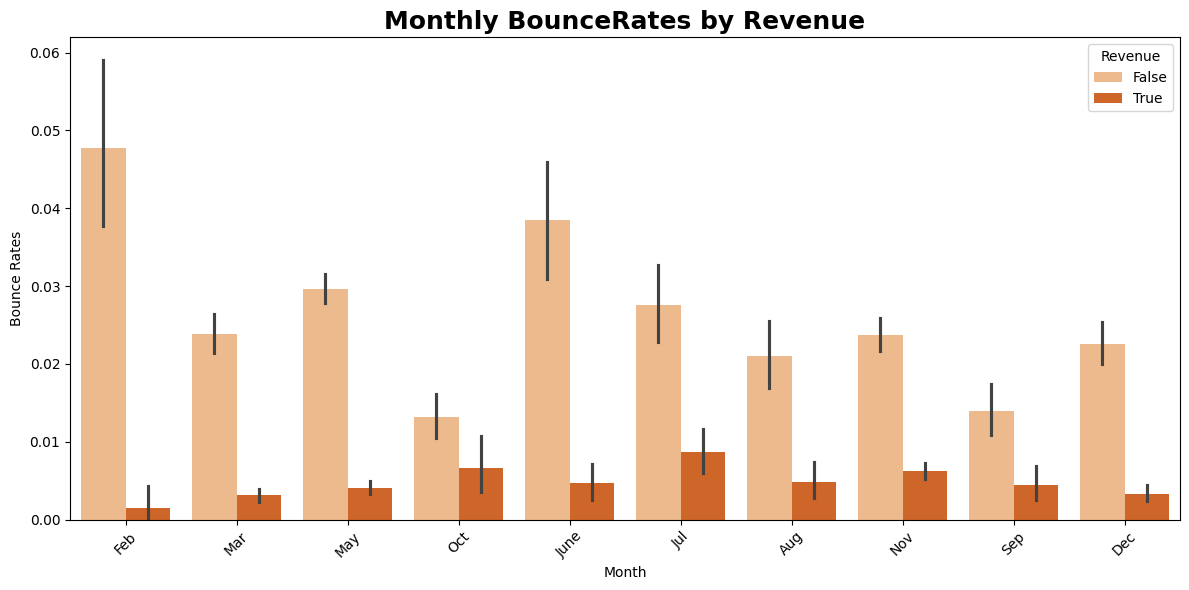

In [25]:
plt.figure(figsize=(12,6))

# Boxplot for Month vs BounceRates with Revenue hue
sns.barplot(
    data=data,
    x='Month',
    y='BounceRates',
    hue='Revenue',
    palette='Oranges'
)

plt.title('Monthly BounceRates by Revenue', fontsize=18, weight='bold')
plt.xlabel('Month')
plt.ylabel('Bounce Rates')
plt.xticks(rotation=45)
plt.legend(title='Revenue', loc='upper right')
plt.tight_layout()
plt.show()

visitor type vs exit rates w.r.t revenue

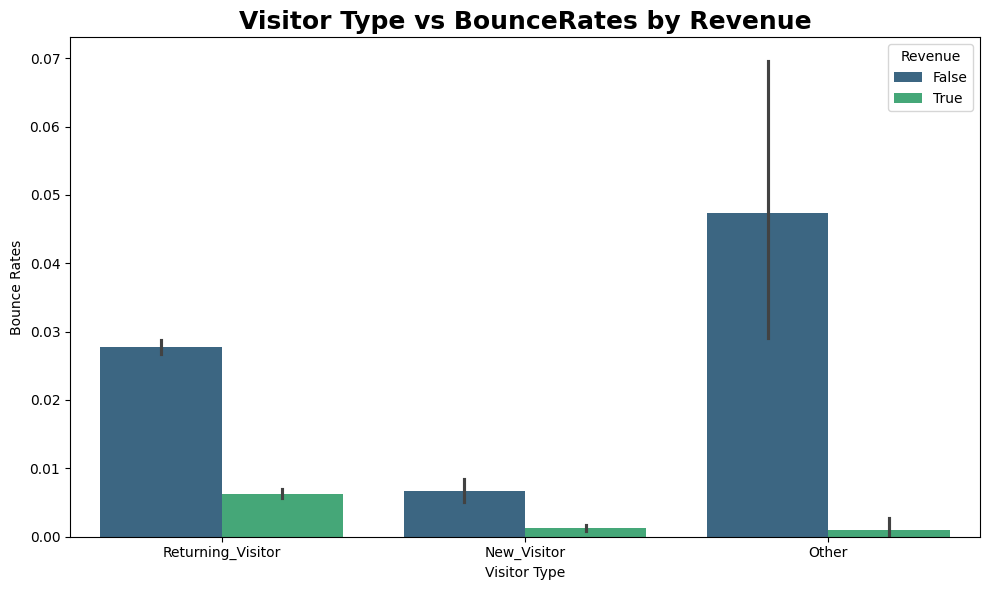

In [26]:
plt.figure(figsize=(10,6))

# Boxplot for VisitorType vs BounceRates with Revenue hue
sns.barplot(
    data=data,
    x='VisitorType',
    y='BounceRates',
    hue='Revenue',
    palette='viridis'
)

plt.title('Visitor Type vs BounceRates by Revenue', fontsize=18, weight='bold')
plt.xlabel('Visitor Type')
plt.ylabel('Bounce Rates')
plt.xticks(rotation=0)  # visitor types are usually short, no need to rotate
plt.legend(title='Revenue', loc='upper right')
plt.tight_layout()
plt.show()

**# MODEL FITTING**

We start with fitting  a baseline model for the analysis. First, lets prepare the data for model fitting. As a first step, we will have to ensure that all the variables are numeric. In the data, there are two variables that are of object type. Lets deal with these before model fitting.

In [27]:
month_map = {
    'Jan':1, 'Feb':2, 'Mar':3, 'Apr':4, 'May':5, 'June':6, 'Jul':7,
    'Aug':8, 'Sep':9, 'Oct':10, 'Nov':11, 'Dec':12
}

data['Month'] = data['Month'].map(month_map)

We apply mapping to ensure that each month has its own numerical mapping that is appropriate.  The second  column of object type is visitor type.  We use pandas categorical in this case.

In [28]:
# Lets convert the column to categorical and then get the codes
data['VisitorType']=data['VisitorType'].astype('category').cat.codes
# confirm that the column is now made of integer
data. info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  int64  
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

We have two columns that are or boolean. These datasets can be fitted like that because assumes a 1 for  True value and a 0 for False.  However, lets convert them to integers

In [29]:
data['Weekend'], data['Revenue'] = data['Weekend'].astype(int), data['Revenue'].astype(int)

In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  int64  
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

### splitting the dataset

In [31]:
y=data['Revenue']
X=data.drop('Revenue', axis=1)
X.shape, y.shape

((12330, 17), (12330,))

In [32]:
X_train, X_test, y_train,y_test = train_test_split (X,y, test_size=0.2, stratify=y)
X_test.shape, y_test.shape

((2466, 17), (2466,))

In [33]:
models = {
    "Logistic": LogisticRegression(max_iter=1000, random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "ExtraTrees": ExtraTreesClassifier(random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42)
}

In [34]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    results.append((name, acc))

results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[LightGBM] [Info] Number of positive: 1526, number of negative: 8338
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002402 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1893
[LightGBM] [Info] Number of data points in the train set: 9864, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.154704 -> initscore=-1.698173
[LightGBM] [Info] Start training from score -1.698173


,Model,Accuracy
9,LightGBM,0.901054
4,GradientBoosting,0.900649
10,CatBoost,0.900649
2,RandomForest,0.899027
8,XGBoost,0.897405
3,ExtraTrees,0.896999
5,AdaBoost,0.884428
0,Logistic,0.877940
1,DecisionTree,0.860503
7,KNN,0.859286


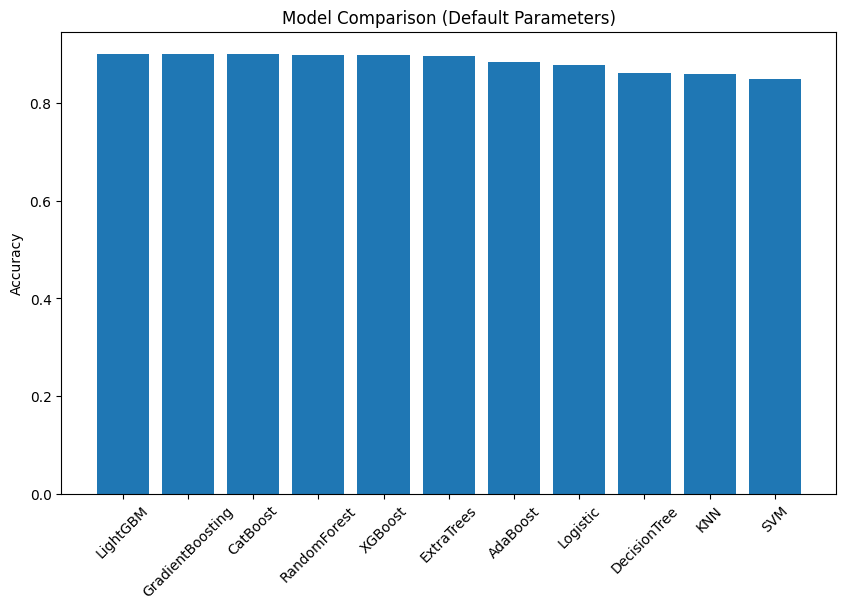

In [35]:
plt.figure(figsize=(10,6))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Comparison (Default Parameters)")
plt.show()

Our models are doing great and have achieved a high accuracy on testt dataset. lets improve the dataset and evaluate how each process improves the model


### Data preparation  2
Here  The goal is to improve the accuracy of the model further.

# The second model fitting process

 Lets first confirm the presence of outliers in the dataset before we can proceed.


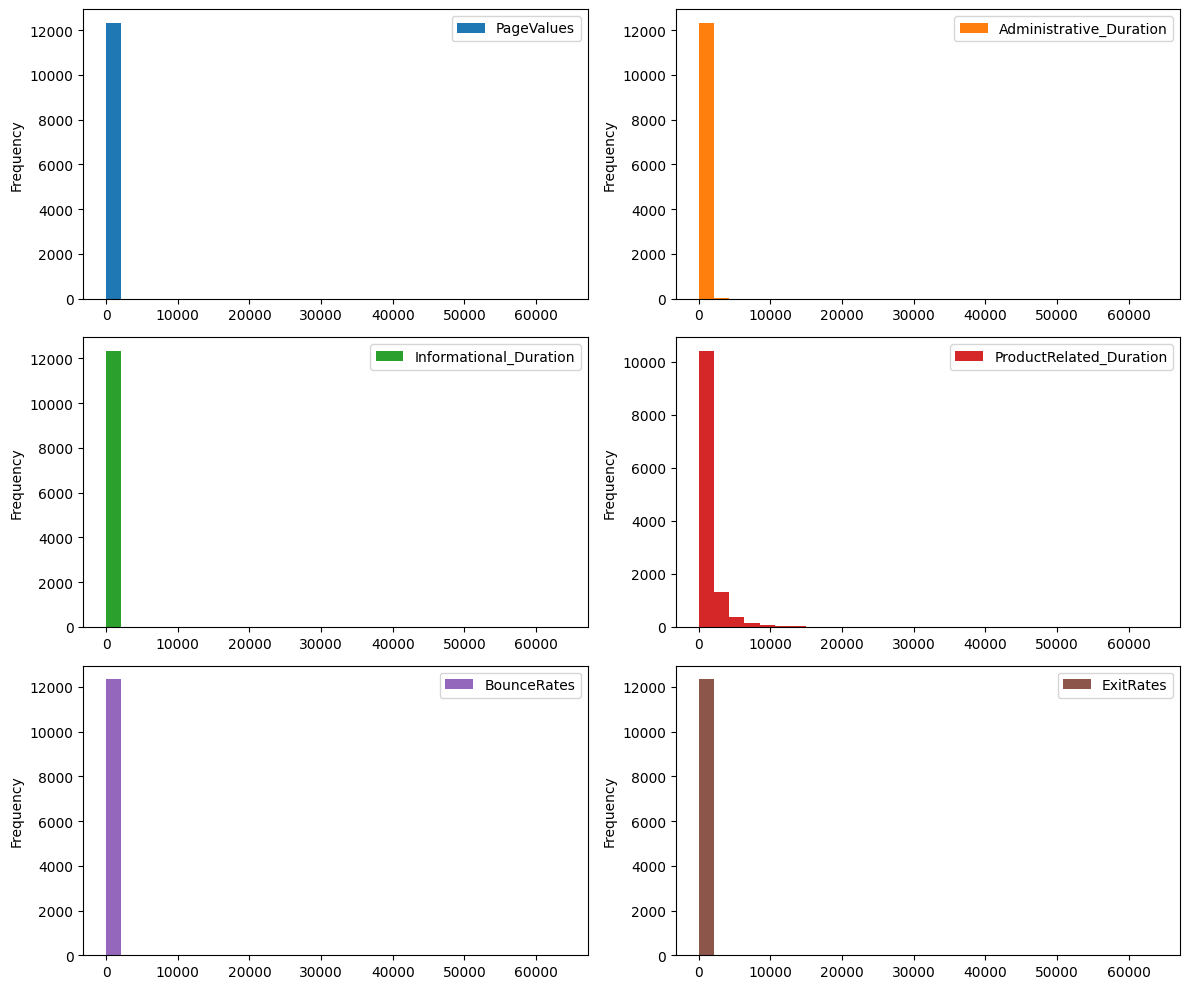

In [36]:
data[['PageValues',
      'Administrative_Duration',
      'Informational_Duration',
      'ProductRelated_Duration',
      'BounceRates',
      'ExitRates']].plot(
        kind='hist',
        bins=30,
        subplots=True,
        layout=(3,2),   # 3 rows, 2 columns
        figsize=(12,10),
        sharex=False
)

plt.tight_layout()
plt.show()

We check for outliers in the continous variables of the dataset as   the other are categorical there is  to check outliers in these. In this case, we find that the  vairables selected to be evaluated for outliers all have outliers. This is depicted in the histogram above as a result.

In [37]:
### Checking for multicollinearity


<Axes: >

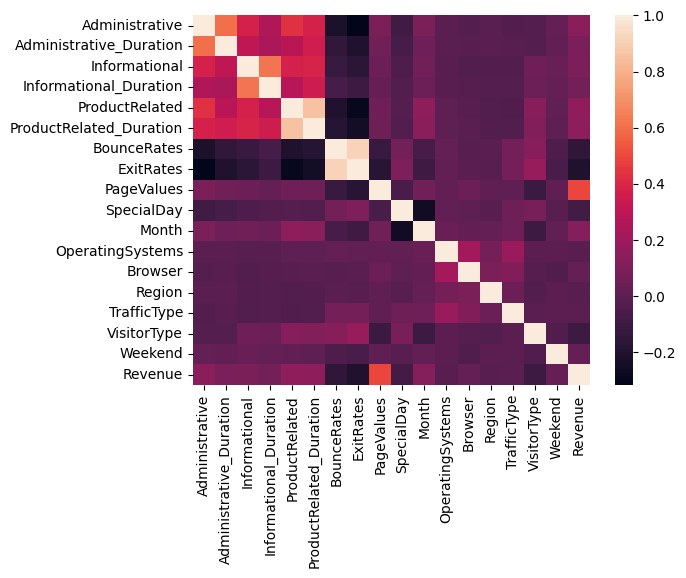

In [38]:
sns.heatmap(data.corr())

High correlation is always an indicator  of multicollinearity. There are some few values that have a high correlation.

In [39]:
cols = [
    'PageValues',
    'Administrative_Duration',
    'Informational_Duration',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates'
]


In [40]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest
from statsmodels.stats.outliers_influence import variance_inflation_factor

from imblearn.over_sampling import SMOTE
from skopt import BayesSearchCV
from skopt.space import Integer, Real


# ─────────────────────────────────────────
# 1. FEATURE ENGINEERING (NO LEAKAGE)
# ─────────────────────────────────────────
def add_features(X, pagevalue_median=None):

    X = X.copy()

    X['Admin_TimePerPage']     = X['Administrative_Duration'] / (X['Administrative'] + 1)
    X['Info_TimePerPage']      = X['Informational_Duration']  / (X['Informational'] + 1)
    X['Product_TimePerPage']   = X['ProductRelated_Duration'] / (X['ProductRelated'] + 1)
    X['Total_Pages']           = X['Administrative'] + X['Informational'] + X['ProductRelated']
    X['Total_Duration']        = X['Administrative_Duration'] + X['Informational_Duration'] + X['ProductRelated_Duration']
    X['Product_PageRatio']     = X['ProductRelated'] / (X['Total_Pages'] + 1)
    X['Product_DurationRatio'] = X['ProductRelated_Duration'] / (X['Total_Duration'] + 1)
    X['Bounce_Exit_Ratio']     = X['BounceRates'] / (X['ExitRates'] + 1e-5)
    X['IsSpecialDay']          = (X['SpecialDay'] > 0).astype(int)
    X['Weekend_Returning']     = X['Weekend'] * X['VisitorType']

    if pagevalue_median is None:
        pagevalue_median = X['PageValues'].median()

    X['HighPageValue'] = (X['PageValues'] > pagevalue_median).astype(int)

    return X, pagevalue_median


# ─────────────────────────────────────────
# 2. VIF REMOVAL
# ─────────────────────────────────────────
def remove_multicollinearity(X, threshold=10):

    X = X.copy()

    while True:
        vif_data = pd.DataFrame()
        vif_data["feature"] = X.columns
        vif_data["VIF"] = [
            variance_inflation_factor(X.values, i)
            for i in range(X.shape[1])
        ]

        max_vif = vif_data["VIF"].max()

        if max_vif > threshold:
            drop_col = vif_data.loc[vif_data["VIF"].idxmax(), "feature"]
            X = X.drop(columns=[drop_col])
        else:
            break

    return X


# ─────────────────────────────────────────
# 3. TRAIN / TEST SPLIT
# ─────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# print(X_train.head())

# ─────────────────────────────────────────
# 4. FEATURE ENGINEERING
# ─────────────────────────────────────────
X_train, median_val = add_features(X_train)
X_test, _ = add_features(X_test, pagevalue_median=median_val)


# ─────────────────────────────────────────
# 5. OUTLIER REMOVAL (TRAIN ONLY)
# ─────────────────────────────────────────
iso = IsolationForest(contamination=0.05, random_state=42)
train_pred = iso.fit_predict(X_train)

mask_train = train_pred == 1
X_train = X_train[mask_train]
y_train = y_train[mask_train]
# print(X_train.head())

# ─────────────────────────────────────────
# 6. VIF REMOVAL (TRAIN ONLY)
# ─────────────────────────────────────────
X_train = remove_multicollinearity(X_train)
X_test = X_test[X_train.columns]

# print(X_train.head())
# ─────────────────────────────────────────
# 7. STANDARD SCALING
# ─────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# print(X_train_scaled.head())
# ─────────────────────────────────────────
# 8. SMOTE (TRAIN ONLY)
# ─────────────────────────────────────────
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled, y_train
)

# print(X_train_resampled.head())
print('Final train data used for model training: ',X_train_resampled.shape)
# ─────────────────────────────────────────
# 9. BASE MODEL COMPARISON
# ─────────────────────────────────────────

results = []

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "F1 Score": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 4),
    })

results_df = pd.DataFrame(results)
print("\n--- BASE MODEL PERFORMANCE ---")
print(results_df)

best_model_name = results_df.sort_values("ROC-AUC", ascending=False).iloc[0]["Model"]
print("\nBest Base Model:", best_model_name)




Final train data used for model training:  (15970, 20)
[LightGBM] [Info] Number of positive: 1385, number of negative: 7985
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001620 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2060
[LightGBM] [Info] Number of data points in the train set: 9370, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.147812 -> initscore=-1.751865
[LightGBM] [Info] Start training from score -1.751865

--- BASE MODEL PERFORMANCE ---
               Model  Accuracy  F1 Score  ROC-AUC
0           Logistic    0.8885    0.6132   0.9001
1       DecisionTree    0.8577    0.5529   0.7394
2       RandomForest    0.8954    0.6206   0.9162
3         ExtraTrees    0.8966    0.6277   0.9141
4   GradientBoosting    0.9002    0.6382   0.9265
5           AdaBoost    0.8897    0.6222   0.9155
6       

In [41]:
from catboost import CatBoostClassifier
import pandas as pd

# Train model
model = CatBoostClassifier(random_state=42, verbose=0)
model.fit(X_train_resampled, y_train_resampled)

# Get feature importances
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,   # ← THIS is correct
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

                    Feature  Importance
6                     Month   20.027758
9                    Region   16.379149
10              TrafficType   15.337674
19            HighPageValue   10.051538
4                PageValues    8.050708
7          OperatingSystems    6.782914
0             Informational    4.013423
8                   Browser    3.801249
13        Admin_TimePerPage    3.207466
1            ProductRelated    2.800827
15      Product_TimePerPage    1.993450
2   ProductRelated_Duration    1.705795
3               BounceRates    1.485130
16        Bounce_Exit_Ratio    1.332725
11              VisitorType    0.944855
14         Info_TimePerPage    0.913657
17             IsSpecialDay    0.355269
18        Weekend_Returning    0.316607
12                  Weekend    0.283921
5                SpecialDay    0.215884


<Axes: ylabel='Feature'>

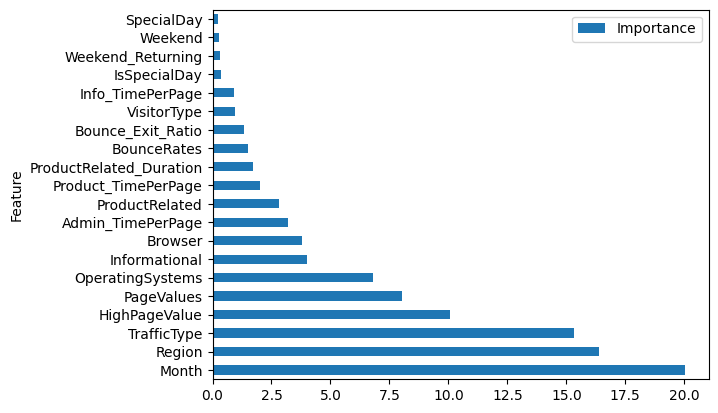

In [42]:
feature_importance_df.set_index('Feature').plot(kind='barh')
